In [ ]:
# imports and config
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, RadioButtons
import ipywidgets as widgets
from matplotlib.patches import Arc
from matplotlib.patches import Ellipse

%matplotlib inline
plt.rcParams['figure.figsize'] = [8, 8]
plt.rcParams['font.size'] = 11
plt.rcParams['axes.linewidth'] = 1.2

---

## Module 1: 2D Rotations

### 1.1 Derivation

Let's track a point $P$ at a distance $r$ from the origin, starting at an initial angle $\phi$. Its position in Cartesian coordinates can be expressed using polar relations:

$$x = r \cos(\phi)$$

$$y = r \sin(\phi)$$

Now, we apply an **active rotation**, which rotates the point counterclockwise about the origin by an angle $\theta$. The radial distance $r$ remains invariant, but the new angle becomes $(\phi + \theta)$. The new position $P'(x', y')$ is defined by:

$$x' = r \cos(\phi + \theta)$$

$$y' = r \sin(\phi + \theta)$$

To express this transformation in terms of the original $(x, y)$ coordinates, we expand the terms using standard trigonometric sum identities:

$$\cos(\phi + \theta) = \cos\phi \cos\theta - \sin\phi \sin\theta$$

$$\sin(\phi + \theta) = \sin\phi \cos\theta + \cos\phi \sin\theta$$

Substitute these back into our $x'$ and $y'$ expressions:

$$x' = r(\cos\phi \cos\theta - \sin\phi \sin\theta) = (r \cos\phi)\cos\theta - (r \sin\phi)\sin\theta$$

$$y' = r(\sin\phi \cos\theta + \cos\phi \sin\theta) = (r \cos\phi)\sin\theta + (r \sin\phi)\cos\theta$$

Recognizing that $r \cos\phi = x$ and $r \sin\phi = y$, we substitute them to obtain the final 2D transformation equations:

$$x' = x \cos\theta - y \sin\theta$$

$$y' = x \sin\theta + y \cos\theta$$

### 1.2 Matrix Representation

Expressing this linear transformation in matrix form offers significant mathematical utility. Primarily, it facilitates **chaining transformations**. By framing rotations as matrices, multiple sequential transformations can be computed seamlessly via matrix multiplication. The composition of several rotations is simply the product of their respective matrices, which elegantly reduces complex algebraic substitutions into a single linear operator.

By extracting the transformation coefficients from our variables, we define the standard **2D Rotation Matrix**, $R(\theta)$:

$$\begin{bmatrix} x' \\ y' \end{bmatrix} = \begin{bmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{bmatrix} \begin{bmatrix} x \\ y \end{bmatrix}$$

In [ ]:
# 2D ROTATIONS

def get_2d_rotation_matrix(theta_deg):
    """
    Computes the 2D rotation matrix for a counterclockwise rotation.
    """
    theta = np.radians(theta_deg)
    c, s = np.cos(theta), np.sin(theta)

    # Constructing the matrix: [[cos, -sin], [sin, cos]]
    return np.array([
        [c, -s],
        [s,  c]
    ])


def plot_2d_rotation(theta_deg):
    """
    Applies the rotation matrix to a geometric shape and plots the result.
    """

    # An asymmetric geometry (triangle) allows us to easily track the orientation
    # Stored as column vectors: [x_1, x_2, x_3...; y_1, y_2, y_3...]
    shape = np.array([
        [0.0, 0.0],   # Vertex 1: Origin
        [2.0, 0.5],   # Vertex 2: Elongated tip
        [0.8, 1.5],   # Vertex 3: Top height
        [0.0, 0.0]    # Close loop back to origin
    ]).T

    # Generate the matrix and perform matrix dot-product multiplication
    R = get_2d_rotation_matrix(theta_deg)
    rotated_shape = R @ shape

    # Plotting setup
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')

    # Draw original shape (Blue)
    ax.plot(shape[0, :], shape[1, :], 'b-o', label='Original Position', alpha=0.4, linewidth=2)
    ax.fill(shape[0, :], shape[1, :], 'b', alpha=0.05)

    # Draw transformed shape (Red)
    ax.plot(rotated_shape[0, :], rotated_shape[1, :], 'r-o', label=f'Rotated Frame ({theta_deg}°)', linewidth=2.5)
    ax.fill(rotated_shape[0, :], rotated_shape[1, :], 'r', alpha=0.15)

    # Render dynamic transformed basis vectors to show the underlying coordinate grid warp
    basis_x, basis_y = np.array([1, 0]), np.array([0, 1])
    rot_bx = R @ basis_x
    rot_by = R @ basis_y

    ax.quiver(0, 0, rot_bx[0], rot_bx[1], angles='xy', scale_units='xy', scale=1, color='darkred', label="New X-Axis Direction")
    ax.quiver(0, 0, rot_by[0], rot_by[1], angles='xy', scale_units='xy', scale=1, color='darkgreen', label="New Y-Axis Direction")

    # Layout and constraint configurations
    ax.set_xlim([-3, 3])
    ax.set_ylim([-3, 3])
    ax.set_aspect('equal')
    ax.grid(True, which='both', linestyle=':', alpha=0.6)
    ax.legend(loc='upper left')
    ax.set_title("2D Active Space Vector Rotation")
    plt.show()

# Connect the plotting pipeline directly to the UI slider module
interact(plot_2d_rotation, theta_deg=FloatSlider(value=30, min=-180, max=180, step=5, description='Angle (°)'));

interactive(children=(FloatSlider(value=30.0, description='Angle (°)', max=180.0, min=-180.0, step=5.0), Outpu…

## Module 2: 3D Rotations

When moving from 2D to 3D space, we no longer rotate "around an origin point." Instead, we rotate **around a directional line called an axis**.

### 2.1 The Three Principal Rotations and the Right-Hand Rule

The standard 3D spatial coordinate system is defined by an ordered set of three mutually orthogonal unit vectors that form an orthonormal basis:

$$\hat{i} = \begin{bmatrix} 1 \\ 0 \\ 0 \end{bmatrix}, \quad \hat{j} = \begin{bmatrix} 0 \\ 1 \\ 0 \end{bmatrix}, \quad \hat{k} = \begin{bmatrix} 0 \\ 0 \\ 1 \end{bmatrix}$$

A rotation matrix $R$ is constructed by placing the transformed basis vectors into the columns of the matrix: $R = \begin{bmatrix} \hat{i}' & \hat{j}' & \hat{k}' \end{bmatrix}$. When rotating about a principal axis by an angle $\theta$, the basis vector corresponding to that axis remains invariant, while the remaining two basis vectors undergo a 2D planar rotation.

#### Rotation around the Z-axis ($R_z$):

The basis vector $\hat{k}$ remains unchanged. The vectors $\hat{i}$ and $\hat{j}$ rotate in the $XY$-plane:


$$R_z(\theta) = \begin{bmatrix} \cos\theta & -\sin\theta & 0 \\ \sin\theta & \cos\theta & 0 \\ 0 & 0 & 1 \end{bmatrix}$$

#### Rotation around the X-axis ($R_x$):

The basis vector $\hat{i}$ remains unchanged. The vectors $\hat{j}$ and $\hat{k}$ rotate in the $YZ$-plane:


$$R_x(\theta) = \begin{bmatrix} 1 & 0 & 0 \\ 0 & \cos\theta & -\sin\theta \\ 0 & \sin\theta & \cos\theta \end{bmatrix}$$

#### Rotation around the Y-axis ($R_y$):

The matrix for rotation about the $Y$-axis exhibits a structural difference that often puzzles students: the signs of the $\sin\theta$ terms are swapped relative to $R_x$ and $R_z$.

$$R_y(\theta) = \begin{bmatrix} \cos\theta & 0 & \sin\theta \\ 0 & 1 & 0 \\ -\sin\theta & 0 & \cos\theta \end{bmatrix}$$

To understand this purely through algebraic structure, we look at the cyclic, directional sequence of a right-handed coordinate system: $X \to Y \to Z \to X$.

When we rotate around an axis, the 2D plane of rotation is formed by the *next two axes* in this cyclic sequence:

* Rotating around $Z$ acts on the ordered pair $(X, Y)$.
* Rotating around $X$ acts on the ordered pair $(Y, Z)$.
* Rotating around $Y$ acts on the ordered pair $(Z, X)$.

Notice that for the $Y$-axis, the correct cyclic order of the remaining dimensions is $(Z, X)$, not $(X, Z)$. If we apply our standard 2D rotation matrix template directly to this cyclic ordering, the coordinates transform as follows:

$$\text{First active axis } (Z): \quad z' = z\cos\theta - x\sin\theta$$

$$\text{Second active axis } (X): \quad x' = z\sin\theta + x\cos\theta$$

When we rearrange these equations back into the standard, non-permuted linear order of $(X, Y, Z)$ to build our matrix, we get:

$$x' = \cos\theta \cdot x + 0 \cdot y + \sin\theta \cdot z$$

$$y' = 0 \cdot x + 1 \cdot y + 0 \cdot z$$

$$z' = -\sin\theta \cdot x + 0 \cdot y + \cos\theta \cdot z$$

Placing these coefficients into rows yields the standard $R_y(\theta)$ matrix. The apparent "sign swap" is simply the algebraic consequence of maintaining a right-handed cyclic order when projecting back onto standard $(X,Y,Z)$ parameters.

### 2.2 Composite Rotations: Intrinsic vs. Extrinsic

Because matrix multiplication is non-commutative ($A \cdot B \neq B \cdot A$), the sequence in which sequential rotations are applied determines the final orientation of the system. We classify compound transformations into two distinct categories based on their frame of reference.

#### Extrinsic Rotations (Fixed Frame)

Extrinsic rotations are performed relative to a static, unchanging global coordinate frame (such as an Earth-fixed reference frame). Every subsequent rotation occurs about the axes of this fixed background system. Mathematically, to rotate a vector step-by-step about fixed axes, each new rotation matrix **pre-multiplies** the existing transformation string. The operators compound from **right to left**:

$$R_{\text{total}} = R_z(\gamma) \cdot R_y(\beta) \cdot R_x(\alpha)$$

#### Intrinsic Rotations (Moving Frame)

Intrinsic rotations are performed relative to a local coordinate frame that is attached to the moving object and changes its orientation with each step. When a rotation is executed, the coordinate axes move along with the body, and the next rotation occurs about these newly updated axes. Mathematically, consecutive intrinsic transformations **post-multiply** the prior state. The operators compound from **left to right**:

$$R_{\text{total}} = R_x(\alpha) \cdot R_y(\beta) \cdot R_z(\gamma)$$

### 2.3 Physical Case Study: The Robotic Manipulator
To bridge the gap between abstract matrix products and physical applications, consider a simple multi-axis industrial robotic arm.

1. **The Base Link (Fixed Frame):** The base of the robot is bolted firmly to the factory floor. We anchor a stationary, global coordinate frame $\{B\}$ here. This frame does not move and acts as our absolute reference frame relative to the Earth.
2. **The End-Effector (Moving Frame):** At the tip of the robot arm is the gripper, or end-effector. We anchor a local, moving coordinate frame $\{E\}$ here. The position and orientation of $\{E\}$ are constantly changing as the arm moves through space.

When the robot executes a task, we describe its motion using our two framing paradigms:

* **Intrinsic Joint Actuation:** When the controller commands the motors at individual joints to spin, it changes the orientation of each link relative to the *preceding link's current position*. Joint 3 rotates about an axis determined entirely by how Joint 1 and Joint 2 have already oriented the arm. This is a purely **intrinsic** sequence modeled via post-multiplication ($R_{\text{base}}^{\text{tip}} = R_1 \cdot R_2 \cdot R_3$), because each joint moves relative to the current local frame established by the previous motor.
* **Extrinsic Path Planning:** If an operator uses a joystick to command the gripper to move straight up along the vertical wall of the room, that command is processed relative to the room itself (the Earth-fixed base frame $\{B\}$). Regardless of how the joints are currently twisted, the commanded rotation must occur about the static global axes of $\{B\}$. This tracking is computed using an **extrinsic** formulation via pre-multiplication.

In [ ]:
# 3D ROTATION MATRICES

def get_3d_rotation_matrix(axis, degrees):
    """
    Returns the corresponding 3x3 principal rotation matrix.
    """
    rad = np.radians(degrees)
    c, s = np.cos(rad), np.sin(rad)

    if axis == 'X':
        return np.array([[1,  0,  0],
                         [0,  c, -s],
                         [0,  s,  c]])
    elif axis == 'Y':
        return np.array([[ c,  0,  s],
                         [ 0,  1,  0],
                         [-s,  0,  c]])
    elif axis == 'Z':
        return np.array([[c, -s,  0],
                         [s,  c,  0],
                         [0,  0,  1]])
    else:
        raise ValueError("Invalid Axis designated.")

def plot_3d_rotation(yaw_z, pitch_y, roll_x, order):
    """
    Combines individual rotations and maps a 3D target geometry.
    """
    # Generate individual principal matrices
    Rz = get_3d_rotation_matrix('Z', yaw_z)
    Ry = get_3d_rotation_matrix('Y', pitch_y)
    Rx = get_3d_rotation_matrix('X', roll_x)

    # Apply proper matrix multiplication chain based on chosen frame reference order
    if order == 'ZYX (Extrinsic / Static Global Frame)':
        # Right-to-Left evaluation matching global system references
        R = Rz @ Ry @ Rx
    else:
        # Left-to-Right evaluation matching localized changes
        R = Rx @ Ry @ Rz

    # Setup 3D plot projection canvas
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Define an asymmetric triangular wedge object in 3D space
    point_cloud = np.array([
        [0.6, 0.1, 0.1],
        [0.1, 0.8, 0.1],
        [0.1, 0.1, 0.8],
        [0.1, 0.1, 0.1]
    ]).T

    # Transform target object using the composite rotation matrix
    transformed_cloud = R @ point_cloud

    # Draw original coordinate frame axes for baseline tracking reference
    origin = np.array([0, 0, 0])
    ax.quiver(*origin, 1, 0, 0, color='blue', linestyle='--', alpha=0.3)
    ax.quiver(*origin, 0, 1, 0, color='green', linestyle='--', alpha=0.3)
    ax.quiver(*origin, 0, 0, 1, color='red', linestyle='--', alpha=0.3)

    # Compute and plot the new location of the local moving frame axes
    local_axes = R @ np.eye(3)
    ax.quiver(*origin, *local_axes[:,0], color='blue', linewidth=2.5, label="New X' (Roll)")
    ax.quiver(*origin, *local_axes[:,1], color='green', linewidth=2.5, label="New Y' (Pitch)")
    ax.quiver(*origin, *local_axes[:,2], color='red', linewidth=2.5, label="New Z' (Yaw)")

    # Render the transformed geometry shape
    ax.scatter(transformed_cloud[0,:], transformed_cloud[1,:], transformed_cloud[2,:], color='purple', s=40)
    ax.plot_trisurf(transformed_cloud[0,:], transformed_cloud[1,:], transformed_cloud[2,:], color='purple', alpha=0.2)

    # Final plot layout adjustments
    ax.set_xlim([-1.2, 1.2])
    ax.set_ylim([-1.2, 1.2])
    ax.set_zlim([-1.2, 1.2])
    ax.set_xlabel('Global X')
    ax.set_ylabel('Global Y')
    ax.set_zlabel('Global Z')
    ax.legend(loc='upper left')
    plt.show()

# Generate interactive dashboard controls with layout styling fixes
interact(plot_3d_rotation,
         yaw_z=FloatSlider(value=45, min=-180, max=180, step=5, description='Yaw (Z)°', style={'description_width': 'initial'}),
         pitch_y=FloatSlider(value=0, min=-180, max=180, step=5, description='Pitch (Y)°', style={'description_width': 'initial'}),
         roll_x=FloatSlider(value=0, min=-180, max=180, step=5, description='Roll (X)°', style={'description_width': 'initial'}),
         order=RadioButtons(
             options=['ZYX (Extrinsic / Static Global Frame)', 'XYZ (Intrinsic / Local Moving Frame)'],
             description='Execution Order:',
             style={'description_width': 'initial'}
         ));

interactive(children=(FloatSlider(value=45.0, description='Yaw (Z)°', max=180.0, min=-180.0, step=5.0, style=S…

---
## Module 3: Homogeneous Coordinates & Rigid Transformations

### 3.1 Why standard 3x3 Matrices Fail
A true rigid transformation requires both **rotation** (spinning) and **translation** (shifting). Mathematically, we write this combined operation as:
$$\mathbf{p'} = R_{3\times3}\mathbf{p} + \mathbf{t}$$

This format creates a major practical problem. Linear transformations *must* always keep the origin $(0,0,0)$ fixed in place. Because translation moves the origin, it is an **affine transformation**, not a linear one.

As a result, we cannot combine rotation and translation into a single $3 \times 3$ matrix multiplication. We are forced to keep rotation ($R\mathbf{p}$) and translation ($+ \mathbf{t}$) as two separate math steps, which makes complex calculations inefficient.

### 3.2 The Solution: Homogeneous Coordinates ($w$)
To solve this, we use a clever mathematical trick: we embed our 3D problem into a 4D space by adding a fourth value, called $w$, to the bottom of our coordinate vectors.

$$\mathbf{P}_{homogeneous} = \begin{bmatrix} x \\ y \\ z \\ w \end{bmatrix}$$

The value we choose for $w$ serves a vital role in keeping our math organized:

* **Points ($w = 1$):** Setting $w=1$ indicates a specific position in space. If you shift space, the position of that point shifts along with it.
* **Vectors / Directions ($w = 0$):** Setting $w=0$ represents a pure direction or velocity, not a location. If you shift a compass arrow pointing East, it still points East. Its position changes, but its direction does not. Setting $w=0$ tells the matrix to ignore translations.

### 3.3 The Special $4 \times 4$ Matrix ($SE(3)$)
By using this extra dimension, we can pack both the $3 \times 3$ rotation matrix and the $3 \times 1$ translation vector into a single, unified $4 \times 4$ transformation matrix:

$$T = \begin{bmatrix} \begin{array}{ccc|c} & & & \\ & R_{3\times3} & & \mathbf{t}_{3\times1} \\ & & & \\ \hline 0 & 0 & 0 & w \end{array} \end{bmatrix} = \begin{bmatrix} r_{11} & r_{12} & r_{13} & t_x \\ r_{21} & r_{22} & r_{23} & t_y \\ r_{31} & r_{32} & r_{33} & t_z \\ 0 & 0 & 0 & 1 \end{bmatrix}$$

Let's look at how this matrix handles a **Point** ($w=1$):
$$T \cdot \begin{bmatrix} x \\ y \\ z \\ 1 \end{bmatrix} = \begin{bmatrix} R_{11}x + R_{12}y + R_{13}z + t_x \\ r_{21}x + r_{22}y + r_{23}z + t_y \\ r_{31}x + r_{32}y + r_{33}z + t_z \\ 0 + 0 + 0 + 1 \end{bmatrix} = \begin{bmatrix} R\mathbf{p} + \mathbf{t} \\ 1 \end{bmatrix}$$
The translation vector $\mathbf{t}$ is successfully added to the position.

Now look at how it handles a directional **Vector** ($w=0$):
$$T \cdot \begin{bmatrix} x \\ y \\ z \\ 0 \end{bmatrix} = \begin{bmatrix} R_{11}x + R_{12}y + R_{13}z + 0 \\ r_{21}x + r_{22}y + r_{23}z + 0 \\ r_{31}x + r_{32}y + r_{33}z + 0 \\ 0 + 0 + 0 + 0 \end{bmatrix} = \begin{bmatrix} R\mathbf{p} \\ 0 \end{bmatrix}$$
Because $w=0$, the translation column is multiplied by zero and safely ignored, preserving the pure directional vector.

### 3.4 Rotating Around an Arbitrary Pivot Point
Standard rotation matrices always spin an object around the global origin $(0,0,0)$. If you try to rotate an object located far from the origin, it will swing along a wide orbit like a planet orbiting the sun.

To spin an object around its own center or a specific pivot point $\mathbf{p}_{pivot}$, we use a three-step matrix chain:
1. **Translate the target to the origin:** Shift space to temporarily move the object's pivot point directly onto $(0,0,0)$.
2. **Rotate:** Spin the object safely around the origin.
3. **Translate back:** Shift space by the inverse amount to return the object to its original location.

In matrix form, this sequence is written and evaluated from right to left:
$$T_{composite} = T_{\text{translate back}} \cdot T_{\text{rotate}} \cdot T_{\text{translate to origin}}$$

In [ ]:
# HOMOGENEOUS TRANSFORMS & PIVOTS

def make_homogeneous_matrix(R, t):
    """
    Assembles a 4x4 homogeneous transformation matrix SE(3)
    from a 3x3 rotation matrix and a 3x1 translation vector.
    """
    T = np.eye(4)
    T[0:3, 0:3] = R
    T[0:3, 3] = t.flatten()
    return T

def simulate_homogeneous_transform(tx, ty, tz, angle_z, use_local_pivot):
    """
    Applies translations and rotations to a 3D cube model.
    """
    # Define a 3D wireframe unit cube using Homogeneous Coordinates
    # Size dimensions: 1x1x1 unit box. Note the bottom row is filled with w=1 (Points)
    cube = np.array([
        [0,0,0,1], [1,0,0,1], [1,1,0,1], [0,1,0,1], # Bottom base square
        [0,0,1,1], [1,0,1,1], [1,1,1,1], [0,1,1,1]  # Top roof square
    ]).T

    # Define transformation parameters
    t_vector = np.array([tx, ty, tz])
    R_matrix = get_3d_rotation_matrix('Z', angle_z)

    # Calculate the geometric center of the cube to use as our local pivot point
    cube_pivot = np.array([0.5, 0.5, 0.5])

    # Construct the transformation matrix chain based on user preference
    if use_local_pivot:
        # Step 1: Shift local center to global origin
        T1 = make_homogeneous_matrix(np.eye(3), -cube_pivot)
        # Step 2: Spin around the origin
        T2 = make_homogeneous_matrix(R_matrix, np.zeros(3))
        # Step 3: Shift back to its position plus any requested translations
        T3 = make_homogeneous_matrix(np.eye(3), cube_pivot + t_vector)

        # Combine the chain into a single master matrix
        T_final = T3 @ T2 @ T1
    else:
        # Standard workflow: Spin around the global origin first, then translate
        T_rot = make_homogeneous_matrix(R_matrix, np.zeros(3))
        T_trans = make_homogeneous_matrix(np.eye(3), t_vector)

        T_final = T_trans @ T_rot

    # Apply the single composite transformation matrix to the entire cube
    transformed_cube = T_final @ cube

    # Setup 3D display rendering pipeline
    fig = plt.figure(figsize=(9, 9))
    ax = fig.add_subplot(111, projection='3d')

    # Index map for drawing the 12 edges of our wireframe cube
    cube_edges = [
        (0,1), (1,2), (2,3), (3,0), # Base face edges
        (4,5), (5,6), (6,7), (7,4), # Top face edges
        (0,4), (1,5), (2,6), (3,7)  # Vertical pillar edges
    ]

    # Draw the initial unrotated reference cube in light gray
    for edge in cube_edges:
        ax.plot(cube[0, [edge[0], edge[1]]],
                cube[1, [edge[0], edge[1]]],
                cube[2, [edge[0], edge[1]]], color='gray', linestyle=':', alpha=0.4)

    # Draw the transformed cube in blue
    for edge in cube_edges:
        ax.plot(transformed_cube[0, [edge[0], edge[1]]],
                transformed_cube[1, [edge[0], edge[1]]],
                transformed_cube[2, [edge[0], edge[1]]], color='blue', linewidth=2)

    # Visual markers to highlight the active pivot point vs the global origin
    ax.scatter(0, 0, 0, color='black', marker='x', s=60, label='Global Origin (0,0,0)')

    if use_local_pivot:
        current_pivot_location = cube_pivot + t_vector
        ax.scatter(*current_pivot_location, color='red', marker='o', s=80, label='Active Local Pivot')

    # Configure graph viewing properties
    ax.set_xlim([-2.0, 3.0])
    ax.set_ylim([-2.0, 3.0])
    ax.set_zlim([-1.0, 3.0])
    ax.set_xlabel('X Space Axis')
    ax.set_ylabel('Y Space Axis')
    ax.set_zlabel('Z Space Axis')
    ax.set_title("Homogeneous Matrix Kinematics Simulation")
    ax.legend(loc='upper left')
    plt.show()

# Instantiate the interactive user dashboard with styling fixes for Colab
interact(simulate_homogeneous_transform,
         tx=FloatSlider(value=1.0, min=-1.0, max=2.0, step=0.1, description='Shift X', style={'description_width': 'initial'}),
         ty=FloatSlider(value=0.5, min=-1.0, max=2.0, step=0.1, description='Shift Y', style={'description_width': 'initial'}),
         tz=FloatSlider(value=0.0, min=-1.0, max=2.0, step=0.1, description='Shift Z', style={'description_width': 'initial'}),
         angle_z=FloatSlider(value=45, min=-180, max=180, step=5, description='Spin (Z)°', style={'description_width': 'initial'}),
         use_local_pivot=widgets.Checkbox(value=True, description='Spin Around Own Center', style={'description_width': 'initial'}));

interactive(children=(FloatSlider(value=1.0, description='Shift X', max=2.0, min=-1.0, style=SliderStyle(descr…

---
## Module 4: The Kinematics of a 2D Planar Arm

We are now ready to build a complete robotic arm. We will model a **Planar RRR Manipulator**.
* **Planar:** It operates strictly in flat 2D space.
* **RRR:** It has three Revolute (rotational) joints.
* **3 DOF:** Three joints give it 3 Degrees of Freedom. In 2D space, you need exactly 3 DOF to control both the $(x, y)$ position of the tool and its orientation angle $\phi$.

Our arm consists of two physical links ($L_1$ and $L_2$). The third joint sits at the end of $L_2$ and simply rotates the end-effector (a semicircular gripper) without adding any extra length.



### 4.1 Forward Kinematics: From Angles to Position
**Forward Kinematics (FK)** answers a simple question: *"If I set my joint motors to specific angles, where will the tip of my robot end up?"*

Because the joints are connected in a chain, the position of each joint depends entirely on the joints before it. This is exactly what we learned in **Intrinsic Rotations**: every joint operates in the moving local coordinate frame of the previous link.

Let's calculate the position of each part of the robot using basic right-triangle trigonometry. The global angle of any link relative to the ground is the sum of all preceding joint angles.

**1. Joint 1 (The Base):**
The base is bolted to the global origin.
$$x_0 = 0$$
$$y_0 = 0$$

**2. Joint 2 (The Elbow):**
The first link has length $L_1$ and rotates by an angle $\theta_1$ relative to the ground.
$$x_1 = L_1 \cos(\theta_1)$$
$$y_1 = L_1 \sin(\theta_1)$$

**3. Joint 3 (The Wrist):**
The second link has length $L_2$. Its motor rotates by $\theta_2$ **relative to Link 1**. Therefore, its absolute global angle is $(\theta_1 + \theta_2)$. To find the wrist's position, we add the new $x$ and $y$ offsets to Joint 2's position:
$$x_2 = x_1 + L_2 \cos(\theta_1 + \theta_2)$$
$$y_2 = y_1 + L_2 \sin(\theta_1 + \theta_2)$$

**4. The End-Effector (The Tool):**
The third motor spins the tool by an angle $\theta_3$ **relative to Link 2**. Because it has no length of its own, its position is exactly the same as the wrist $(x_2, y_2)$. Its final global orientation angle $\phi$, however, is the sum of all the intrinsic joint rotations:
$$\phi = \theta_1 + \theta_2 + \theta_3$$

Because there is only one unique set of mathematical outputs for any given set of input angles, Forward Kinematics is a straightforward, linear calculation.

In [ ]:
# FORWARD KINEMATICS SIMULATION

def plot_fk(theta1_deg, theta2_deg, theta3_deg):
    """
    Computes Forward Kinematics for a 3DOF 2D robotic arm and plots the result.
    """
    # Robot Physical Parameters
    L1 = 2.0  # Length of link 1
    L2 = 1.5  # Length of link 2

    # Convert angles to radians
    t1 = np.radians(theta1_deg)
    t2 = np.radians(theta2_deg)
    t3 = np.radians(theta3_deg)

    # Forward Kinematics Equations
    # Base
    x0, y0 = 0.0, 0.0

    # Elbow (Joint 2)
    x1 = L1 * np.cos(t1)
    y1 = L1 * np.sin(t1)

    # Wrist (Joint 3 / Tool Base)
    x2 = x1 + L2 * np.cos(t1 + t2)
    y2 = y1 + L2 * np.sin(t1 + t2)

    # End Effector Global Orientation
    phi = t1 + t2 + t3

    # Plotting Setup
    fig, ax = plt.subplots(figsize=(8, 8))

    # Draw the links
    ax.plot([x0, x1], [y0, y1], 'k-', linewidth=4, label='Link 1')
    ax.plot([x1, x2], [y1, y2], 'b-', linewidth=4, label='Link 2')

    # Draw the joints
    ax.plot(x0, y0, 'ko', markersize=10) # Base
    ax.plot(x1, y1, 'ko', markersize=8)  # Elbow
    ax.plot(x2, y2, 'ro', markersize=8, label='Wrist (J3)') # Wrist

    # Draw the End-Effector (Semicircle Gripper facing outward)
    # Changing theta1 to 90 and theta2 to 270 makes the "C" shape open away from the arm
    gripper_radius = 0.6
    phi_deg = np.degrees(phi)
    gripper = Arc((x2, y2), gripper_radius, gripper_radius,
                  angle=phi_deg, theta1=90, theta2=270,
                  color='red', linewidth=3, label='End-Effector Orientation')
    ax.add_patch(gripper)

    # Draw a line showing the tool center point direction
    tip_x = x2 + (gripper_radius/2) * np.cos(phi)
    tip_y = y2 + (gripper_radius/2) * np.sin(phi)
    ax.plot([x2, tip_x], [y2, tip_y], 'r--', linewidth=2)

    # Annotations and Layout
    ax.set_xlim([-4.0, 4.0])
    ax.set_ylim([-4.0, 4.0])
    ax.set_aspect('equal')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_title(f"Forward Kinematics\nTip Pos: ({x2:.2f}, {y2:.2f}) | Orientation: {phi_deg:.1f}°")
    ax.legend(loc='upper right')
    plt.show()

# Interactive Dashboard for FK
interact(plot_fk,
         theta1_deg=FloatSlider(value=45, min=-180, max=180, step=5, description='Joint 1 (Base)°', style={'description_width': 'initial'}),
         theta2_deg=FloatSlider(value=-30, min=-180, max=180, step=5, description='Joint 2 (Elbow)°', style={'description_width': 'initial'}),
         theta3_deg=FloatSlider(value=0, min=-180, max=180, step=5, description='Joint 3 (Wrist)°', style={'description_width': 'initial'}));

interactive(children=(FloatSlider(value=45.0, description='Joint 1 (Base)°', max=180.0, min=-180.0, step=5.0, …

---

### 4.2 Inverse Kinematics: The Goal-Oriented Problem

**Inverse Kinematics (IK)** flips the script. Instead of providing the joint angles, you dictate the final state to the robot: *"I want your end-effector to grab an object at coordinates $(x, y)$, facing a global angle $\phi$. Figure out how to bend your joints to get there."*

This is vastly more mathematically complex than Forward Kinematics due to non-linearities:

1. **Unreachable Targets:** If the target distance is greater than the total length of the arm ($L_1 + L_2$), there is no real mathematical solution. The equations will literally break down.
2. **Multiple Solutions:** To reach a point in front of you, you can bend your elbow up toward the ceiling, or down toward the floor. A single $(x, y)$ coordinate yields multiple valid mathematical angle configurations.

#### The Math: Deconstructing the Geometry

Because our specific arm has a tool with zero length (the final motor purely rotates the gripper in place), the target coordinate $(x, y)$ is exactly the position of the **Wrist** (Joint 3).

To find the required joint angles, we must construct a geometric model. Draw an imaginary straight line from the Base $(0,0)$ to the Wrist $(x,y)$. Let's call the length of this line $R$. You have now formed a triangle with three sides: $L_1$, $L_2$, and $R$.

**Step 1: Find the distance to target ($R$)**
Before looking at angles, we need the length of the imaginary line $R$. Because the Base is at the origin $(0,0)$, we can simply build a right triangle with the $X$ and $Y$ axes and apply the Pythagorean theorem:


$$R^2 = x^2 + y^2$$

**Step 2: Solve for the Elbow Angle ($\theta_2$)**
We must find how much Joint 2 bends relative to Link 1. Look at the triangle formed by $L_1$, $L_2$, and $R$. Let the internal angle opposite to side $R$ be $\beta$.

The **Law of Cosines** relates the lengths of the sides of a triangle to its internal angles:


$$R^2 = L_1^2 + L_2^2 - 2 L_1 L_2 \cos(\beta)$$

However, $\beta$ is the *internal* angle. The motor angle $\theta_2$ is the *external* angle—how far Link 2 has deviated from its fully extended position. Because a straight line is $180^\circ$, these two angles are supplementary: $\beta = 180^\circ - \theta_2$.

Using the trigonometric identity $\cos(180^\circ - \theta_2) = -\cos(\theta_2)$, we substitute this into our Law of Cosines equation:


$$R^2 = L_1^2 + L_2^2 - 2 L_1 L_2 (-\cos(\theta_2))$$

$$R^2 = L_1^2 + L_2^2 + 2 L_1 L_2 \cos(\theta_2)$$

Now, we use standard algebra to isolate $\cos(\theta_2)$:


$$\cos(\theta_2) = \frac{R^2 - L_1^2 - L_2^2}{2 L_1 L_2}$$

To find the actual angle, we could just use inverse cosine ($\arccos$). However, standard $\arccos$ only gives us one positive angle. Remember our "Elbow Up" and "Elbow Down" problem? We actually have *two* valid solutions.

We find them using the Pythagorean identity $\sin^2(\theta) + \cos^2(\theta) = 1$. Rearranging this gives us two possible values for the sine of the angle (one positive, one negative):


$$\sin(\theta_2) = \pm\sqrt{1 - \cos^2(\theta_2)}$$

By passing both the sine and cosine components into the `atan2` programming function, we can extract the precise $\theta_2$ angle for both the "Elbow Up" (negative sine) and "Elbow Down" (positive sine) configurations.

**Step 3: Solve for the Base Angle ($\theta_1$)**
Now we must find the angle of Link 1 relative to the global $X$-axis. We can break this into two smaller angles:

1. **$\gamma$**: The absolute global angle of our imaginary line $R$.
2. **$\alpha$**: The internal angle between the imaginary line $R$ and Link 1.

Finding $\gamma$ is a standard trigonometric conversion from Cartesian to polar coordinates using the global origin and the wrist coordinate $(x, y)$:


$$\gamma = \text{atan2}(y, x)$$

Finding $\alpha$ requires resolving the position of the Wrist joint into orthogonal components relative to Link 1. By treating Link 1 as the primary axis of a localized coordinate frame, we can project the vector of Link 2 onto this new frame:

* The component **parallel** to Link 1 is the length of Link 1 plus the parallel projection of Link 2: $L_1 + L_2 \cos(\theta_2)$.
* The component **perpendicular** (normal) to Link 1 is strictly the normal projection of Link 2: $L_2 \sin(\theta_2)$.

These two orthogonal vector components define a right triangle where $\alpha$ is the angle between Link 1 and the hypotenuse $R$. Using the definition of the tangent function (opposite over adjacent):


$$\tan(\alpha) = \frac{L_2 \sin(\theta_2)}{L_1 + L_2 \cos(\theta_2)}$$

$$\alpha = \text{atan2}(L_2 \sin(\theta_2), \, L_1 + L_2 \cos(\theta_2))$$

Because we defined the total global angle $\gamma$, and the localized offset angle $\alpha$, the final base angle $\theta_1$ is simply their difference:


$$\theta_1 = \gamma - \alpha$$


*(Note: Because we preserved the true positive/negative sign of $\theta_2$ in Step 2, this single subtraction equation elegantly handles both Elbow Up and Elbow Down configurations without needing conditional logic).*

**Step 4: Solve for the Wrist Angle ($\theta_3$)**
Because we mapped our end-effector position directly to the Wrist joint $(x, y)$, we only have one constraint left to satisfy: the final tool orientation $\phi$.

From our Forward Kinematics derivations, we know that the absolute global orientation of the final link in a 2D planar arm is simply the sum of all intrinsic joint rotations:


$$\phi = \theta_1 + \theta_2 + \theta_3$$

Since we have already solved for $\theta_1$ and $\theta_2$, we algebraically isolate $\theta_3$:


$$\theta_3 = \phi - \theta_1 - \theta_2$$

Thus we've geometrically derived the 'exact' joint angles required for our robot to produce a particular pose. \
These angles are 'exact' as they have been found analytically by solving an equation with discrete solutions (elbow up or down). \
However the same is not the case in IK solvers for higher DOF(s) where you need to pick an 'optimal' solution from many possible solutions.

In [ ]:
# INVERSE KINEMATICS SIMULATION

def plot_ik(target_x, target_y, target_phi_deg, elbow_config):
    """
    Computes Inverse Kinematics to reach a specific (x,y) and orientation,
    and plots the calculated robot posture.
    """
    L1 = 2.0
    L2 = 1.5
    phi = np.radians(target_phi_deg)

    # -----------------------------------
    # Step 1: Reachability Check
    # -----------------------------------
    R_squared = target_x**2 + target_y**2
    R = np.sqrt(R_squared)

    fig, ax = plt.subplots(figsize=(8, 8))

    if R > (L1 + L2) or R < abs(L1 - L2):
        # Target is outside the robot's physical workspace envelope
        ax.text(0, 0, f"TARGET OUT OF REACH\nDistance: {R:.2f} | Max Reach: {L1+L2}",
                ha='center', va='center', fontsize=14, color='red', fontweight='bold')
        ax.set_xlim([-4.0, 4.0])
        ax.set_ylim([-4.0, 4.0])
        ax.axis('off')
        plt.show()
        return

    # -----------------------------------
    # Step 2: Solve for Theta 2 (Elbow)
    # -----------------------------------
    cos_theta2 = (R_squared - L1**2 - L2**2) / (2 * L1 * L2)

    # Prevent math domain errors due to floating point precision limits
    cos_theta2 = np.clip(cos_theta2, -1.0, 1.0)

    # Use positive sin for Elbow Down, negative for Elbow Up
    sin_theta2 = np.sqrt(1 - cos_theta2**2)
    if elbow_config == 'Elbow Up':
        sin_theta2 = -sin_theta2

    t2 = np.arctan2(sin_theta2, cos_theta2)

    # -----------------------------------
    # Step 3: Solve for Theta 1 (Base)
    # -----------------------------------
    gamma = np.arctan2(target_y, target_x)
    alpha = np.arctan2(L2 * sin_theta2, L1 + L2 * cos_theta2)
    t1 = gamma - alpha

    # -----------------------------------
    # Step 4: Solve for Theta 3 (Wrist)
    # -----------------------------------
    t3 = phi - t1 - t2

    # -----------------------------------
    # Plotting pipeline using our derived angles
    # -----------------------------------
    x0, y0 = 0.0, 0.0
    x1 = L1 * np.cos(t1)
    y1 = L1 * np.sin(t1)
    x2 = x1 + L2 * np.cos(t1 + t2)
    y2 = y1 + L2 * np.sin(t1 + t2)

    # Draw Links and Joints
    ax.plot([x0, x1], [y0, y1], 'k-', linewidth=4, label='Link 1')
    ax.plot([x1, x2], [y1, y2], 'b-', linewidth=4, label='Link 2')
    ax.plot(x0, y0, 'ko', markersize=10)
    ax.plot(x1, y1, 'ko', markersize=8)
    ax.plot(x2, y2, 'ro', markersize=8)

    # Draw Target Marker (Star)
    ax.plot(target_x, target_y, 'g*', markersize=15, label='Commanded Target Point')

    # Draw End Effector (Semicircle Gripper facing outward)
    gripper_radius = 0.6
    gripper = Arc((x2, y2), gripper_radius, gripper_radius,
                  angle=target_phi_deg, theta1=90, theta2=270,
                  color='red', linewidth=3)
    ax.add_patch(gripper)

    tip_x = x2 + (gripper_radius/2) * np.cos(phi)
    tip_y = y2 + (gripper_radius/2) * np.sin(phi)
    ax.plot([x2, tip_x], [y2, tip_y], 'r--', linewidth=2)

    # Annotations and formatting
    t1_deg, t2_deg, t3_deg = np.degrees(t1), np.degrees(t2), np.degrees(t3)
    ax.set_xlim([-4.0, 4.0])
    ax.set_ylim([-4.0, 4.0])
    ax.set_aspect('equal')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_title(f"Inverse Kinematics Computed Path\nMotors Set To: [J1: {t1_deg:.1f}°, J2: {t2_deg:.1f}°, J3: {t3_deg:.1f}°]")
    ax.legend(loc='upper right')
    plt.show()

# Interactive Dashboard for IK
interact(plot_ik,
         target_x=FloatSlider(value=1.5, min=-3.5, max=3.5, step=0.1, description='Target X', style={'description_width': 'initial'}),
         target_y=FloatSlider(value=2.0, min=-3.5, max=3.5, step=0.1, description='Target Y', style={'description_width': 'initial'}),
         target_phi_deg=FloatSlider(value=45, min=-180, max=180, step=5, description='Target Orientation°', style={'description_width': 'initial'}),
         elbow_config=RadioButtons(options=['Elbow Down', 'Elbow Up'], description='IK Solution Set:', style={'description_width': 'initial'}));

interactive(children=(FloatSlider(value=1.5, description='Target X', max=3.5, min=-3.5, style=SliderStyle(desc…

---

### 5.1 Velocity Kinematics: The Jacobian Matrix

In robotics, the **Jacobian ($J$)** is a matrix of partial derivatives that maps velocities in **Joint Space** (how fast the motors spin) to velocities in **Task Space** (how fast the end-effector moves in Cartesian coordinates).

Mathematically, this relationship is expressed as:


$$\dot{X} = J \dot{q}$$

Where:

* **$\dot{X}$** is the linear and angular velocity vector of the end-effector: $\begin{bmatrix} \dot{x} \\ \dot{y} \\ \dot{\phi} \end{bmatrix}$
* **$\dot{q}$** is the velocity vector of the joints: $\begin{bmatrix} \dot{\theta_1} \\ \dot{\theta_2} \\ \dot{\theta_3} \end{bmatrix}$

#### Step 1: Define the Forward Kinematics State

To find the partial derivatives, we first need the baseline Forward Kinematics position equations for our tool center point (Wrist). Since our third joint only rotates the tool in place, the position $(x, y)$ is purely governed by $\theta_1$ and $\theta_2$, while the orientation $\phi$ is governed by all three.

$$x = L_1 \cos(\theta_1) + L_2 \cos(\theta_1 + \theta_2)$$

$$y = L_1 \sin(\theta_1) + L_2 \sin(\theta_1 + \theta_2)$$

$$\phi = \theta_1 + \theta_2 + \theta_3$$

#### Step 2: Set Up the Partial Derivative Matrix

The Jacobian matrix is constructed by taking the partial derivative of each spatial coordinate ($x, y, \phi$) with respect to each joint angle ($\theta_1, \theta_2, \theta_3$). For our 3-DOF arm, this results in a $3 \times 3$ matrix:

$$J = \begin{bmatrix}
\frac{\partial x}{\partial \theta_1} & \frac{\partial x}{\partial \theta_2} & \frac{\partial x}{\partial \theta_3} \\
\frac{\partial y}{\partial \theta_1} & \frac{\partial y}{\partial \theta_2} & \frac{\partial y}{\partial \theta_3} \\
\frac{\partial \phi}{\partial \theta_1} & \frac{\partial \phi}{\partial \theta_2} & \frac{\partial \phi}{\partial \theta_3}
\end{bmatrix}$$

#### Step 3: Compute the Derivatives

We will evaluate the partial derivatives row by row using the chain rule.

**Row 1: Linear X Velocity ($\dot{x}$)**

* $\frac{\partial x}{\partial \theta_1} = -L_1 \sin(\theta_1) - L_2 \sin(\theta_1 + \theta_2)$
* $\frac{\partial x}{\partial \theta_2} = -L_2 \sin(\theta_1 + \theta_2)$
* $\frac{\partial x}{\partial \theta_3} = 0$ *(Joint 3 does not affect X position)*

**Row 2: Linear Y Velocity ($\dot{y}$)**

* $\frac{\partial y}{\partial \theta_1} = L_1 \cos(\theta_1) + L_2 \cos(\theta_1 + \theta_2)$
* $\frac{\partial y}{\partial \theta_2} = L_2 \cos(\theta_1 + \theta_2)$
* $\frac{\partial y}{\partial \theta_3} = 0$ *(Joint 3 does not affect Y position)*

**Row 3: Angular Velocity ($\dot{\phi}$)**

* $\frac{\partial \phi}{\partial \theta_1} = 1$
* $\frac{\partial \phi}{\partial \theta_2} = 1$
* $\frac{\partial \phi}{\partial \theta_3} = 1$

#### Step 4: The Final Analytical Jacobian

Compiling all of our derived terms, the complete analytical Jacobian for our 3-DOF planar arm is:

$$J = \begin{bmatrix}
-L_1 \sin(\theta_1) - L_2 \sin(\theta_1 + \theta_2) & -L_2 \sin(\theta_1 + \theta_2) & 0 \\
L_1 \cos(\theta_1) + L_2 \cos(\theta_1 + \theta_2) & L_2 \cos(\theta_1 + \theta_2) & 0 \\
1 & 1 & 1
\end{bmatrix}$$

### 5.2 Analyzing the Matrix Properties

Looking closely at this derived matrix reveals key physical behaviors of the robot:

1. **The Zero Column:** The entire final column for $x$ and $y$ is exactly $0$. This mathematically proves what we already logically defined: spinning the wrist motor ($\theta_3$) has zero physical impact on the $(x, y)$ position of the tool center point.
2. **Singularities (Gimbal Lock for Robots):** If you take the determinant of the top-left $2 \times 2$ block (which governs linear velocity), you get $\det(J_v) = L_1 L_2 \sin(\theta_2)$.
* If $\theta_2 = 0^\circ$ (arm is fully outstretched) or $\theta_2 = 180^\circ$ (arm is completely folded back), the $\sin(\theta_2)$ becomes $0$, making the determinant $0$.
* When the determinant of a Jacobian is $0$, the matrix loses rank. This is called a **Kinematic Singularity**. In this state, the arm physically cannot move in certain directions no matter how fast the motors spin, and Inverse Velocity equations (which require dividing by the determinant) will trigger division-by-zero errors in the robot's control software.

---

### 5.3 Inverse Velocity Kinematics: The Control Engine

While forward velocity kinematics maps joint speeds to Cartesian tracking, the real-world operational problem is reversed. An engineer dictates how fast the robot's hand must trace a path—specifying linear and angular velocities $\dot{X}$—and the controller must instantaneously compute the matching motor speeds $\dot{q}$.

This operational pipeline requires the **Inverse Jacobian Matrix** ($J^{-1}$):

$$\dot{q} = J^{-1} \dot{X}$$

#### Step 1: The Anatomy of Our Jacobian and Block Partitioning

Finding the analytical inverse of a full $3 \times 3$ matrix using standard algebra is a massive, error-prone undertaking. However, if we look closely at the Jacobian we derived for our 3-DOF arm, it has a highly specific structure:

$$J = \begin{bmatrix}
\frac{\partial x}{\partial \theta_1} & \frac{\partial x}{\partial \theta_2} & 0 \\
\frac{\partial y}{\partial \theta_1} & \frac{\partial y}{\partial \theta_2} & 0 \\
1 & 1 & 1
\end{bmatrix}$$

Notice the top right corner: because Joint 3 only rotates the tool and doesn't change its $(x, y)$ position, those partial derivatives are exactly $0$. We can use this to our advantage by slicing the $3 \times 3$ matrix into four smaller "blocks":

$$J = \begin{bmatrix} J_v & \mathbf{0} \\ \mathbf{1}^T & 1 \end{bmatrix}$$

Where:

* **$J_v$** (Top Left): The $2 \times 2$ sub-matrix governing linear Cartesian velocities $(\dot{x}, \dot{y})$.
* **$\mathbf{0}$** (Top Right): A $2 \times 1$ column vector of zeros.
* **$\mathbf{1}^T$** (Bottom Left): A $1 \times 2$ row vector of ones $[1, 1]$.
* **$1$** (Bottom Right): The $1 \times 1$ scalar representing Joint 3's direct 1:1 impact on the tool's orientation.

#### Step 2: The Magic of Block Matrix Inversion

Because the top-right block is entirely zeros, our Jacobian is what mathematicians call a **block lower-triangular matrix**.

For any block lower-triangular matrix $M = \begin{bmatrix} A & \mathbf{0} \\ C & D \end{bmatrix}$, there is a proven algebraic identity for its inverse:


$$M^{-1} = \begin{bmatrix} A^{-1} & \mathbf{0} \\ -D^{-1} C A^{-1} & D^{-1} \end{bmatrix}$$

*Why does this work?* If you multiply $M$ by $M^{-1}$, the zeros cancel out the complex cross-terms, perfectly yielding the Identity Matrix ($I$).

Applying this identity to our specific partitioned Jacobian (where $A = J_v$, $C = \mathbf{1}^T$, and $D = 1$), the inverse formula simplifies beautifully because dividing by $1$ does nothing:


$$J^{-1} = \begin{bmatrix} J_v^{-1} & \mathbf{0} \\ -\mathbf{1}^T J_v^{-1} & 1 \end{bmatrix}$$

This identity proves that we don't need to invert a massive $3 \times 3$ matrix. We only need to invert the $2 \times 2$ positional matrix ($J_v$), and the rest of the puzzle pieces will fall into place.

#### Step 3: Inverting the $2 \times 2$ Linear Sub-Matrix ($J_v$)

The algebraic inverse of any $2 \times 2$ matrix $A = \begin{bmatrix} a & b \\ c & d \end{bmatrix}$ is found by calculating its determinant ($\det$), swapping the main diagonal elements, negating the off-diagonal elements, and dividing by the determinant:


$$A^{-1} = \frac{1}{\det(A)} \begin{bmatrix} d & -b \\ -c & a \end{bmatrix}$$

First, we isolate the determinant of $J_v$:


$$\det(J_v) = \left(-L_1 \sin(\theta_1) - L_2 \sin(\theta_1 + \theta_2)\right)\left(L_2 \cos(\theta_1 + \theta_2)\right) - \left(-L_2 \sin(\theta_1 + \theta_2)\right)\left(L_1 \cos(\theta_1) + L_2 \cos(\theta_1 + \theta_2)\right)$$

Expanding these products cancels out the non-linear scaling terms of Link 2 entirely, reducing the expression to:


$$\det(J_v) = L_1 L_2 \left( \sin(\theta_1+\theta_2)\cos(\theta_1) - \cos(\theta_1+\theta_2)\sin(\theta_1) \right)$$

Applying the standard trigonometric difference identity $\sin(A - B) = \sin(A)\cos(B) - \cos(A)\sin(B)$:


$$\det(J_v) = L_1 L_2 \sin((\theta_1 + \theta_2) - \theta_1) = L_1 L_2 \sin(\theta_2)$$

With the determinant solved, our $2 \times 2$ inverse ($J_v^{-1}$) is:


$$J_v^{-1} = \frac{1}{L_1 L_2 \sin(\theta_2)} \begin{bmatrix} L_2 \cos(\theta_1 + \theta_2) & L_2 \sin(\theta_1 + \theta_2) \\ -L_1 \cos(\theta_1) - L_2 \cos(\theta_1 + \theta_2) & -L_1 \sin(\theta_1) - L_2 \sin(\theta_1 + \theta_2) \end{bmatrix}$$

#### Step 4: Resolving the Bottom Row

To complete the bottom row of our block system ($-\mathbf{1}^T J_v^{-1}$), we must multiply our new $J_v^{-1}$ matrix by the row vector $[-1, -1]$. In matrix multiplication, multiplying by a vector of ones simply sums the rows together.

Summing the top row and bottom row of $J_v^{-1}$ gives us:


$$\text{Sum} = \frac{1}{L_1 L_2 \sin(\theta_2)} \begin{bmatrix} -L_1 \cos(\theta_1) & -L_1 \sin(\theta_1) \end{bmatrix}$$

This is the bottom-left $1 \times 2$ block of our final matrix.

#### Step 5: Assembling the Final Matrix Overview

Now we place all our blocks back into the $3 \times 3$ structure.

To make the final equation clean, we want to factor out the scalar determinant $\frac{1}{L_1 L_2 \sin(\theta_2)}$ from the *entire* matrix, placing it out front. Because we factored this out globally, we must multiply the bottom-right element (which was just $1$) by $L_1 L_2 \sin(\theta_2)$ to keep its true mathematical value unchanged.

This yields our absolute **Analytical Inverse Jacobian**:

$$J^{-1} = \frac{1}{L_1 L_2 \sin(\theta_2)} \begin{bmatrix}
L_2 \cos(\theta_1 + \theta_2) & L_2 \sin(\theta_1 + \theta_2) & 0 \\
-L_1 \cos(\theta_1) - L_2 \cos(\theta_1 + \theta_2) & -L_1 \sin(\theta_1) - L_2 \sin(\theta_1 + \theta_2) & 0 \\
L_1 \cos(\theta_1) & L_1 \sin(\theta_1) & L_1 L_2 \sin(\theta_2)
\end{bmatrix}$$

### 5.4 Reading the Matrix: What Does This Actually Tell Us?

Looking at the final $J^{-1}$ matrix gives us profound insights into how this specific 3-DOF robot behaves dynamically:

1. **The Decoupled Wrist:** Look at the rightmost column. The top two elements are exactly $0$. This means if you command a change in angular velocity ($\dot{\phi}$) without asking for a change in linear position ($\dot{x}, \dot{y}$), the equations for Joint 1 ($\dot{\theta_1}$) and Joint 2 ($\dot{\theta_2}$) output exactly zero. The math proves that the arm's position and orientation are decoupled; you only need to spin Joint 3 to spin the tool in place.
2. **The Base Adjustments:** Look at the bottom row. Even though Joint 3 is decoupled from position, if you command the robot to move in $X$ or $Y$, Joint 1 and 2 *will* change the orientation of the tool as they swing. The bottom row calculates exactly how much Joint 3 needs to spin backward or forward to compensate for the arm's movement and keep the tool perfectly leveled along your commanded $\phi$ trajectory.
3. **The Singularity Trap:** The entire matrix is scaled by $\frac{1}{\sin(\theta_2)}$. If $\theta_2$ approaches $0^\circ$ (arm fully extended) or $180^\circ$ (arm folded perfectly back), $\sin(\theta_2)$ approaches zero. This forces a division by zero. Physically, this means commanding the arm to move radially outward when it is already fully extended would require infinite motor velocity—a Kinematic Singularity.

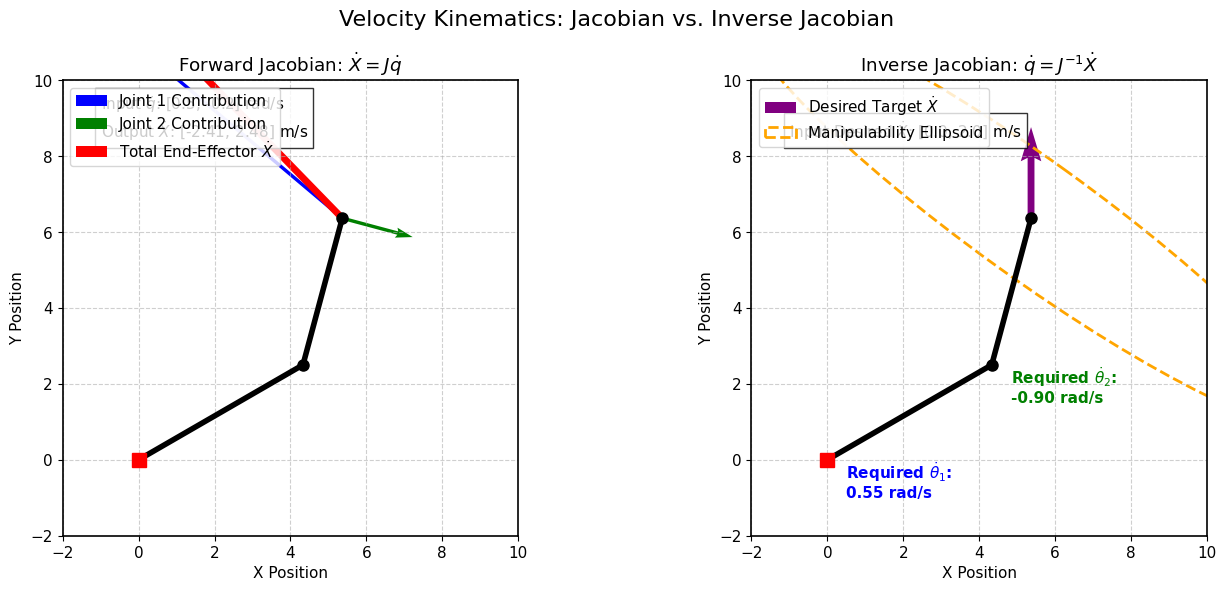

In [ ]:
# JACOBIAN AND INVERSE JACOBIAN

# --- 1. Robot Parameters & State ---
L1 = 5.0
L2 = 4.0

# Current joint angles (radians)
theta1 = np.radians(30)
theta2 = np.radians(45)
theta3 = np.radians(0)

# --- 2. Forward Kinematics (Position) ---
x1 = L1 * np.cos(theta1)
y1 = L1 * np.sin(theta1)
x2 = x1 + L2 * np.cos(theta1 + theta2)
y2 = y1 + L2 * np.sin(theta1 + theta2)

# --- 3. The Analytical Jacobian (Linear subset Jv) ---
J_v = np.array([
    [-L1 * np.sin(theta1) - L2 * np.sin(theta1 + theta2), -L2 * np.sin(theta1 + theta2)],
    [ L1 * np.cos(theta1) + L2 * np.cos(theta1 + theta2),  L2 * np.cos(theta1 + theta2)]
])

# Inverse Jacobian (Jv^-1), though we've derived it as well
J_v_inv = np.linalg.inv(J_v)

# --- 4. Setup the Plot ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Velocity Kinematics: Jacobian vs. Inverse Jacobian', fontsize=16)

def draw_arm(ax, title):
    ax.plot([0, x1, x2], [0, y1, y2], 'ko-', linewidth=4, markersize=8)
    ax.plot(0, 0, 'rs', markersize=10) # Base
    ax.set_xlim(-2, 10)
    ax.set_ylim(-2, 10)
    ax.set_aspect('equal')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_title(title)
    ax.set_xlabel('X Position')
    ax.set_ylabel('Y Position')

# ==========================================
# PLOT 1: Forward Jacobian (Joints -> Task)
# ==========================================
draw_arm(ax1, r'Forward Jacobian: $\dot{X} = J \dot{q}$')

# We command specific motor speeds (rad/s)
q_dot = np.array([0.5, -0.2]) # Joint 1 moves +0.5, Joint 2 moves -0.2

# Calculate resulting end-effector velocity
X_dot = J_v.dot(q_dot)

# Plot the individual joint contributions and total velocity
# Joint 1's contribution if it moved alone
v1 = J_v[:, 0] * q_dot[0]
ax1.quiver(x2, y2, v1[0], v1[1], color='blue', scale=5, label='Joint 1 Contribution')

# Joint 2's contribution if it moved alone
v2 = J_v[:, 1] * q_dot[1]
ax1.quiver(x2, y2, v2[0], v2[1], color='green', scale=5, label='Joint 2 Contribution')

# Total resulting velocity
ax1.quiver(x2, y2, X_dot[0], X_dot[1], color='red', scale=5, width=0.015, label=r'Total End-Effector $\dot{X}$')

ax1.legend(loc='upper left')
ax1.text(-1, 8.5, rf"Input $\dot{{q}}$: [{q_dot[0]}, {q_dot[1]}] rad/s{chr(10)}Output $\dot{{X}}$: [{X_dot[0]:.2f}, {X_dot[1]:.2f}] m/s",
         bbox=dict(facecolor='white', alpha=0.8))

# ==========================================
# PLOT 2: Inverse Jacobian (Task -> Joints)
# ==========================================
draw_arm(ax2, r'Inverse Jacobian: $\dot{q} = J^{-1} \dot{X}$')

# We command a specific end-effector direction (e.g., straight UP)
X_dot_desired = np.array([0.0, 2.0])

# Calculate required joint speeds
q_dot_required = J_v_inv.dot(X_dot_desired)

# Plot the desired Cartesian velocity
ax2.quiver(x2, y2, X_dot_desired[0], X_dot_desired[1], color='purple', scale=10, width=0.015, label=r'Desired Target $\dot{X}$')

# Visualize the calculated Joint Velocities as text near the joints
ax2.text(0.5, -1, rf"Required $\dot{{\theta}}_1$:{chr(10)}{q_dot_required[0]:.2f} rad/s", color='blue', fontweight='bold')
ax2.text(x1+0.5, y1-1, rf"Required $\dot{{\theta}}_2$:{chr(10)}{q_dot_required[1]:.2f} rad/s", color='green', fontweight='bold')

# --- Bonus: Manipulability Ellipsoid ---
# This visualizes how easily the robot can move in all directions
U, S, V = np.linalg.svd(J_v)
angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
ell = Ellipse(xy=(x2, y2), width=S[0]*2, height=S[1]*2, angle=angle,
              edgecolor='orange', fc='none', lw=2, linestyle='--', label='Manipulability Ellipsoid')
ax2.add_patch(ell)

ax2.legend(loc='upper left')
ax2.text(-1, 8.5, rf"Input Desired $\dot{{X}}$: [{X_dot_desired[0]}, {X_dot_desired[1]}] m/s",
         bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()